In [1]:
import pandas as pd 
import numpy as np 
from numpy.lib.stride_tricks import sliding_window_view
import torch 
import torch.nn as nn 
from torch.utils.data import TensorDataset, DataLoader
from pytorch_tcn import TCN 

import matplotlib.pyplot as plt 

In [2]:
stocks_df = pd.read_csv("sp500_stocks.csv") 

In [3]:
# hyper-y parameters on features we want 
DEVICE = torch.device("mps" if torch.mps.is_available() else "cpu") 
LOOKBACK = 30 # how many previous days of data we get 
FEATURES = ["open", "high", "low", "close", "volume"] # nothing, just lagged columns 
HORIZONS = [1, 7, 30] # these are in trading days, not calendar days. Could possibly cause some problems later 
                             # this will actually change in the target columns of the data loader if you care to customize in this way 

BATCH_SIZE = 64 
HMAX = max(HORIZONS)

df = stocks_df.copy()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["symbol","date"]).reset_index(drop=True)

Xl, yl = [], []

for _, g in df.groupby("symbol", sort=False):
    x = g[FEATURES].to_numpy(np.float32)

    ### Normazlizing; especially important for volume, because otherwise loss explodes and has no way of coming down 
    mu = x.mean(axis=0)
    sigma = x.std(axis=0) + 1e-8
    x = (x - mu) / sigma
    c = g["close"].to_numpy(np.float32)
    T = len(g)
    if T < LOOKBACK + HMAX: 
        continue

    w = sliding_window_view(x, LOOKBACK, axis=0)
    n = T - LOOKBACK - HMAX + 1
    if n <= 0:
        continue

    X = w[:n].transpose(0,2,1)
    b = c[LOOKBACK-1:LOOKBACK-1+n]

    y = np.stack([(c[LOOKBACK-1+h:LOOKBACK-1+h+n]/b - 1) for h in HORIZONS],1).astype(np.float32)

    Xl.append(X); yl.append(y)

X = torch.tensor(np.concatenate(Xl), dtype=torch.float32)
y = torch.tensor(np.concatenate(yl), dtype=torch.float32)

n = len(X)
idx = torch.arange(n)

first_cutoff = int(0.7*n)
second_cutoff = int(0.9*n)

train = TensorDataset(X[:first_cutoff], y[:first_cutoff])
val   = TensorDataset(X[first_cutoff:second_cutoff], y[first_cutoff:second_cutoff])
test  = TensorDataset(X[second_cutoff:], y[second_cutoff])

train_loader = DataLoader(train, BATCH_SIZE, shuffle=True, drop_last=True, num_workers = 4, persistent_workers = True, pin_memory = True)
val_loader   = DataLoader(val, BATCH_SIZE)
test_loader  = DataLoader(test, BATCH_SIZE)

In [ ]:
EPOCHS = 1 
LR = 3e-4 
WEIGHT_DECAY = 2e-6 


model = TCN(
    num_inputs = 5, # one channel for each feature we have 
    num_channels = [16, 32, 64, 64],
    dilation_reset = 32, # to stop the kernels from trying to expand beyond the length of the inputs they're getting (default is dilation works as 2^n) 
    kernel_size = 3,
    dropout = 0.1,
    causal = True,
    use_skip_connections = True,
    output_projection = 3,
    input_shape = "NLC", 
).to(DEVICE)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY   # L2 regularization
)


train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    model.train()

    running_train_loss = 0.0

    for step, (X_batch, y_batch) in enumerate(train_loader):

        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()

        output = model(X_batch)

        preds = output[:, -1, :]

        loss = criterion(preds, y_batch)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

        train_losses.append(loss.item())


        if not step % 500: 
            print(
                f"Epoch {epoch+1}/{EPOCHS} | "
                f"Step {step}/{len(train_loader)} | "
                f"Train Loss: {loss.item():.6f}"
            )

    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            output = model(X_batch)

            preds = output[:, -1, :]

            loss = criterion(preds, y_batch)

            running_val_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    avg_val_loss = running_val_loss / len(val_loader)

    val_losses.append(avg_val_loss)

    print(
        f"\nEpoch {epoch+1} Complete | "
        f"Avg Train Loss: {avg_train_loss:.6f} | "
        f"Avg Val Loss: {avg_val_loss:.6f}\n"
    )

'''model.eval()

test_loss = 0.0

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        output = model(X_batch)

        preds = output[:, -1, :]

        loss = criterion(preds, y_batch)

        test_loss += loss.item()

test_loss /= len(test_loader)

print(f"Test Loss: {test_loss:.6f}")'''

/opt/homebrew/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/1 | Step 1/31646 | Train Loss: 0.130019
Epoch 1/1 | Step 501/31646 | Train Loss: 0.007305
Epoch 1/1 | Step 1001/31646 | Train Loss: 0.005246
Epoch 1/1 | Step 1501/31646 | Train Loss: 0.010831
Epoch 1/1 | Step 2001/31646 | Train Loss: 0.007065
Epoch 1/1 | Step 2501/31646 | Train Loss: 0.004351
Epoch 1/1 | Step 3001/31646 | Train Loss: 0.007626
Epoch 1/1 | Step 3501/31646 | Train Loss: 0.005207
Epoch 1/1 | Step 4001/31646 | Train Loss: 0.005609
Epoch 1/1 | Step 4501/31646 | Train Loss: 0.010755
Epoch 1/1 | Step 5001/31646 | Train Loss: 0.005195
Epoch 1/1 | Step 5501/31646 | Train Loss: 0.005609
Epoch 1/1 | Step 6001/31646 | Train Loss: 0.006344
Epoch 1/1 | Step 6501/31646 | Train Loss: 0.007339
Epoch 1/1 | Step 7001/31646 | Train Loss: 0.004726
Epoch 1/1 | Step 7501/31646 | Train Loss: 0.005463
Epoch 1/1 | Step 8001/31646 | Train Loss: 0.004810
Epoch 1/1 | Step 8501/31646 | Train Loss: 0.003599
Epoch 1/1 | Step 9001/31646 | Train Loss: 0.010038
Epoch 1/1 | Step 9501/31646 | Train

IndexError: index 3 is out of bounds for dimension 0 with size 3

In [5]:
torch.save(
    {
        "model_state": model.state_dict(),
        "config": {
            "num_inputs": 5,
            "num_channels": [16, 24, 24, 32],
            "kernel_size": 3,
            "dropout": 0.1,
            "causal": True,
            "use_skip_connections": True,
            "output_projection": 3,
            "input_shape": "NLC",
        }
    },
    "tcn_model.pt"
)

## If needed later: 
'''ckpt = torch.load("tcn_model.pt", map_location=DEVICE)

model = TCN(**ckpt["config"]).to(DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()'''

'ckpt = torch.load("tcn_model.pt", map_location=DEVICE)\n\nmodel = TCN(**ckpt["config"]).to(DEVICE)\nmodel.load_state_dict(ckpt["model_state"])\nmodel.eval()'

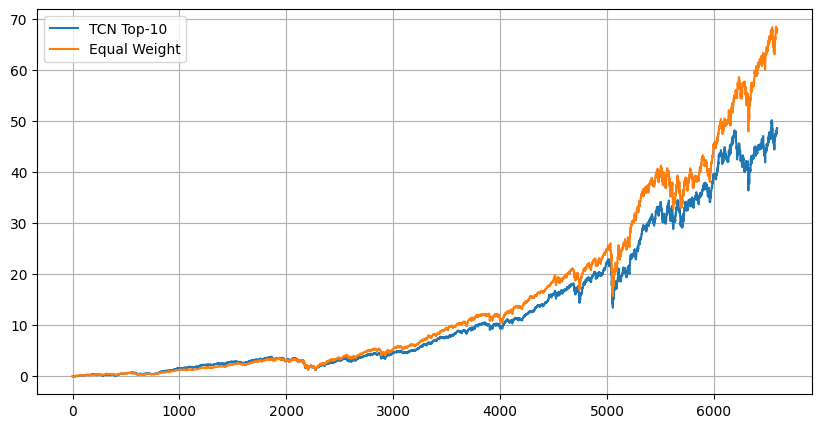

In [10]:
# Code for evaluating the model (full credit to ChatGPT here): 
model.eval()

df = stocks_df.copy()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["symbol", "date"]).reset_index(drop=True)

df["next_ret"] = df.groupby("symbol")["close"].shift(-1) / df["close"] - 1
df = df.dropna(subset=["next_ret"])

groups = {
    s: {
        "x": g[FEATURES].to_numpy(np.float32),
        "ret": g["next_ret"].to_numpy(np.float32),
        "date": g["date"].to_numpy()
    }
    for s, g in df.groupby("symbol")
}

dates = sorted(df["date"].unique())

top10_r, eq_r = [], []
k
for d in dates:

    X_list, R_list = [], []

    for s, g in groups.items():

        dates_s = g["date"]
        idx = np.where(dates_s == d)[0]

        if len(idx) == 0:
            continue

        i = idx[0]
        if i < 30:
            continue

        x = g["x"][i-30:i]          # (30, 5)
        r = g["ret"][i]

        # enforce shape safety
        if x.shape != (30, 5):
            continue

        mu = x.mean(axis=0)
        std = x.std(axis=0) + 1e-8
        x = (x - mu) / std

        X_list.append(x)
        R_list.append(r)

    if len(X_list) < 10:
        continue


    X = np.stack(X_list)  # (N, 30, 5)
    R = np.array(R_list)

    assert X.shape[1:] == (30, 5)

    X = torch.tensor(X, dtype=torch.float32, device=DEVICE)


    with torch.no_grad():
        preds = model(X)[:, -1, 0].cpu().numpy()  # (N,)


    top_idx = np.argsort(preds)[-10:]

    top10_r.append(R[top_idx].mean())
    eq_r.append(R.mean())


top10_curve = np.cumprod(1 + np.array(top10_r)) - 1
eq_curve = np.cumprod(1 + np.array(eq_r)) - 1

plt.figure(figsize=(10,5))
plt.plot(top10_curve, label="TCN Top-10")
plt.plot(eq_curve, label="Equal Weight")
plt.legend()
plt.grid()
plt.show()

In [4]:
### SAME THING AGAIN, BUT ONLY ON RECENT DATA + 50 LARGEST STOCKS 
rec_popdf = df.copy() 

# Same 50 large-cap tickers used in supervised models.ipynb
tickers = [
    "NVDA","GOOGL","AAPL","MSFT","AMZN",
    "META","AVGO","TSLA","BRK-B","LLY",
    "JPM","V","XOM","MA","UNH",
    "JNJ","PG","COST","HD","CVX",
    "ABBV","PEP","KO","MRK","CSCO",
    "ADBE","CRM","ORCL","NFLX","WMT",
    "MCD","TMO","AMD","INTC","ACN",
    "IBM","QCOM","TXN","AXP","GS",
    "MS","BLK","SPGI","INTU","BKNG",
    "SBUX","NKE","RTX","LMT","GE"
]

start_date = pd.to_datetime("2016-04-30")
end_date = pd.to_datetime("2026-04-30") 

rec_popdf = rec_popdf[
    (rec_popdf["date"] >= start_date)
    & (rec_popdf["date"] <= end_date)
    & (rec_popdf["symbol"].isin(tickers))
].reset_index()

Xl, yl = [], []

for _, g in rec_popdf.groupby("symbol", sort=False):
    x = g[FEATURES].to_numpy(np.float32)

    ### Normazlizing; especially important for volume, because otherwise loss explodes and has no way of coming down 
    mu = x.mean(axis=0)
    sigma = x.std(axis=0) + 1e-8
    x = (x - mu) / sigma
    c = g["close"].to_numpy(np.float32)
    T = len(g)
    if T < LOOKBACK + HMAX: 
        continue

    w = sliding_window_view(x, LOOKBACK, axis=0)
    n = T - LOOKBACK - HMAX + 1
    if n <= 0:
        continue

    X = w[:n].transpose(0,2,1)
    b = c[LOOKBACK-1:LOOKBACK-1+n]

    y = np.stack([(c[LOOKBACK-1+h:LOOKBACK-1+h+n]/b - 1) for h in HORIZONS],1).astype(np.float32)

    Xl.append(X); yl.append(y)

X = torch.tensor(np.concatenate(Xl), dtype=torch.float32)
y = torch.tensor(np.concatenate(yl), dtype=torch.float32)

n = len(X)
idx = torch.arange(n)

first_cutoff = int(0.7*n)
second_cutoff = int(0.9*n)

train = TensorDataset(X[:first_cutoff], y[:first_cutoff])
val   = TensorDataset(X[first_cutoff:second_cutoff], y[first_cutoff:second_cutoff])
test  = TensorDataset(X[second_cutoff:], y[second_cutoff])

train_loader = DataLoader(train, BATCH_SIZE, shuffle=True, drop_last=True, num_workers = 4, persistent_workers = True, pin_memory = True)
val_loader   = DataLoader(val, BATCH_SIZE)
test_loader  = DataLoader(test, BATCH_SIZE)

In [ ]:
EPOCHS = 5 
LR = 3e-4 
WEIGHT_DECAY = 2e-6 


model = TCN(
    num_inputs = 5, # one channel for each feature we have 
    num_channels = [16, 72, 72, 72],
    dilation_reset = 32, # to stop the kernels from trying to expand beyond the length of the inputs they're getting (default is dilation works as 2^n) 
    kernel_size = 3,
    dropout = 0.1,
    causal = True,
    use_skip_connections = True,
    output_projection = 3,
    input_shape = "NLC", 
).to(DEVICE)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY   # L2 regularization
)


train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    model.train()

    running_train_loss = 0.0

    for step, (X_batch, y_batch) in enumerate(train_loader):

        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()

        output = model(X_batch)

        preds = output[:, -1, :]

        loss = criterion(preds, y_batch)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

        train_losses.append(loss.item())

    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            output = model(X_batch)

            preds = output[:, -1, :]

            loss = criterion(preds, y_batch)

            running_val_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    avg_val_loss = running_val_loss / len(val_loader)

    val_losses.append(avg_val_loss)

    print(
        f"\nEpoch {epoch+1} Complete | "
        f"Avg Train Loss: {avg_train_loss:.6f} | "
        f"Avg Val Loss: {avg_val_loss:.6f}\n"
    )

'''model.eval()

test_loss = 0.0

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        output = model(X_batch)

        preds = output[:, -1, :]

        loss = criterion(preds, y_batch)

        test_loss += loss.item()

test_loss /= len(test_loader)

print(f"Test Loss: {test_loss:.6f}")'''

/opt/homebrew/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



Epoch 1 Complete | Avg Train Loss: 0.005309 | Avg Val Loss: 0.006346


Epoch 2 Complete | Avg Train Loss: 0.004283 | Avg Val Loss: 0.006274


Epoch 3 Complete | Avg Train Loss: 0.004227 | Avg Val Loss: 0.006313


Epoch 4 Complete | Avg Train Loss: 0.004201 | Avg Val Loss: 0.006286



KeyboardInterrupt: 

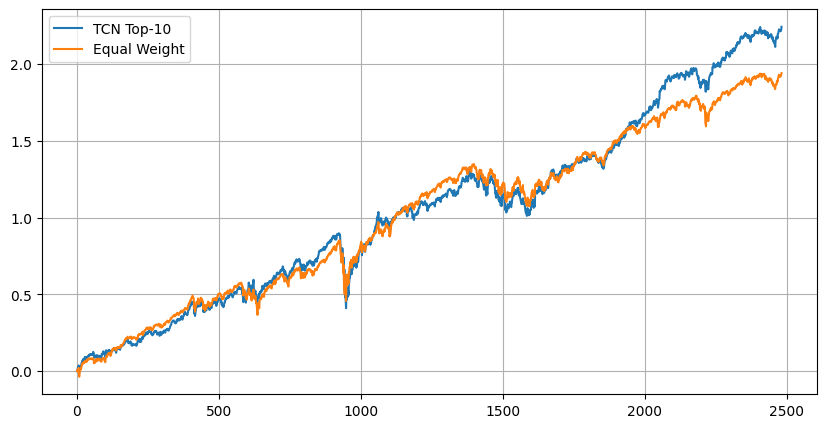

In [10]:
# Code for evaluating the model (full credit to ChatGPT here): 
model.eval()

graphing_df = rec_popdf.copy()
graphing_df["date"] = pd.to_datetime(graphing_df["date"])
graphing_df = graphing_df.sort_values(["symbol", "date"]).reset_index(drop=True)

graphing_df["next_ret"] = graphing_df.groupby("symbol")["close"].shift(-1) / graphing_df["close"] - 1
graphing_df = graphing_df.dropna(subset=["next_ret"])

groups = {
    s: {
        "x": g[FEATURES].to_numpy(np.float32),
        "ret": g["next_ret"].to_numpy(np.float32),
        "date": g["date"].to_numpy()
    }
    for s, g in graphing_df.groupby("symbol")
}

dates = sorted(graphing_df["date"].unique())

top10_r, eq_r = [], []

for d in dates:

    X_list, R_list = [], []

    for s, g in groups.items():

        dates_s = g["date"]
        idx = np.where(dates_s == d)[0]

        if len(idx) == 0:
            continue

        i = idx[0]
        if i < 30:
            continue

        x = g["x"][i-30:i]          # (30, 5)
        r = g["ret"][i]

        # enforce shape safety
        if x.shape != (30, 5):
            continue

        mu = x.mean(axis=0)
        std = x.std(axis=0) + 1e-8
        x = (x - mu) / std

        X_list.append(x)
        R_list.append(r)

    if len(X_list) < 10:
        continue


    X = np.stack(X_list)  # (N, 30, 5)
    R = np.array(R_list)

    assert X.shape[1:] == (30, 5)

    X = torch.tensor(X, dtype=torch.float32, device=DEVICE)


    with torch.no_grad():
        preds = model(X)[:, -1, 0].cpu().numpy()  # (N,)


    top_idx = np.argsort(preds)[-10:]

    top10_r.append(R[top_idx].mean())
    eq_r.append(R.mean())


top10_curve = np.log(np.cumprod(1 + np.array(top10_r))) 
eq_curve = np.log(np.cumprod(1 + np.array(eq_r))) 

plt.figure(figsize=(10,5))
plt.plot(top10_curve, label="TCN Top-10")
plt.plot(eq_curve, label="Equal Weight")
plt.legend()
plt.grid()
plt.show()